# Bitcoin Market Sentiment vs Trader Performance


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

plt.rcParams['figure.figsize']=(10,5)
sns.set_style('whitegrid')


Upload `historical_data.csv` and `fear_greed_index.csv` to the Colab here together.


In [3]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [50]:
hist = pd.read_csv('historical_data.csv')
fear = pd.read_csv('fear_greed_index.csv')

print(hist.head())

print(hist.columns)
print(fear.head())
print(fear.columns)


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [51]:
# -------- Data Cleaning --------
hist.columns=[c.strip().lower().replace(' ','_') for c in hist.columns]
fear.columns=[c.strip().lower().replace(' ','_') for c in fear.columns]

hist['timestamp_ist'] = pd.to_datetime(hist['timestamp_ist'], format='%d-%m-%Y %H:%M')
fear['date'] = pd.to_datetime(fear['date'])

hist['date'] = hist['timestamp_ist'].dt.date
fear['date'] = fear['date'].dt.date

# detect sentiment column
sent_col=[c for c in fear.columns if 'class' in c or 'fear' in c or 'value' in c][-1]
fear=fear[['date',sent_col]].rename(columns={sent_col:'sentiment'})

In [52]:
# Merge
df=hist.merge(fear,on='date',how='left')
print(df.shape)
df.head()

(211224, 18)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [60]:
# Detect pnl column
pnl=[c for c in df.columns if 'pnl' in c][0]
df[pnl]=pd.to_numeric(df[pnl],errors='coerce')

# Clean up any rows where sentiment is still missing before describing
df_clean = df.dropna(subset=['sentiment'])

if not df_clean.empty:
    print(df_clean.groupby('sentiment')[pnl].describe())
else:
    print("Warning: No matching sentiment data found for the dates in historical data.")

                 count       mean          std           min  25%  50%  \
sentiment                                                                
Extreme Fear   21400.0  34.537862  1136.056091  -31036.69194  0.0  0.0   
Extreme Greed  39992.0  67.892861   766.828294  -10259.46800  0.0  0.0   
Fear           61837.0  54.290400   935.355438  -35681.74723  0.0  0.0   
Greed          50303.0  42.743559  1116.028390 -117990.10410  0.0  0.0   
Neutral        37686.0  34.307718   517.122220  -24500.00000  0.0  0.0   

                     75%           max  
sentiment                               
Extreme Fear    5.635032  115287.00000  
Extreme Greed  10.028709   44223.45187  
Fear            5.590856  135329.09010  
Greed           4.944105   74530.52371  
Neutral         3.995795   48504.09555  


In [61]:
# Closing-trades-only
closers = df[df[pnl] != 0]
print(f"Closing trades: {len(closers)} / {len(df)} ({len(closers)/len(df):.1%})")
print(closers.groupby('sentiment')[pnl].describe())

Closing trades: 104408 / 211224 (49.4%)
                 count        mean          std           min       25%  \
sentiment                                                                 
Extreme Fear   10406.0   71.027316  1628.408341  -31036.69194  0.024314   
Extreme Greed  20853.0  130.205309  1058.126139  -10259.46800  1.143404   
Fear           29808.0  112.625988  1344.778427  -35681.74723  0.628873   
Greed          25176.0   85.403927  1576.394764 -117990.10410  0.049465   
Neutral        18159.0   71.199993   743.212863  -24500.00000  0.224754   

                    50%        75%           max  
sentiment                                         
Extreme Fear   6.388050  44.111504  115287.00000  
Extreme Greed  8.530740  44.441362   44223.45187  
Fear           6.350483  40.268687  135329.09010  
Greed          4.927600  36.918150   74530.52371  
Neutral        4.583458  29.024415   48504.09555  


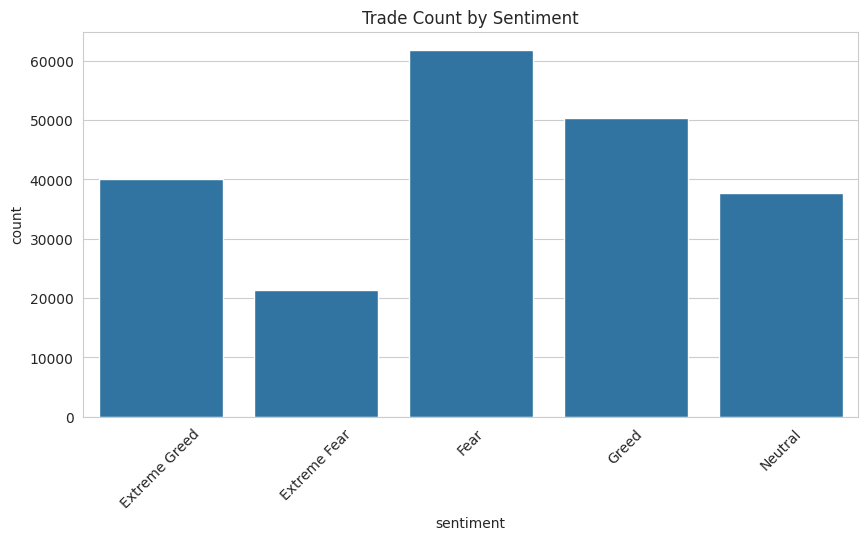

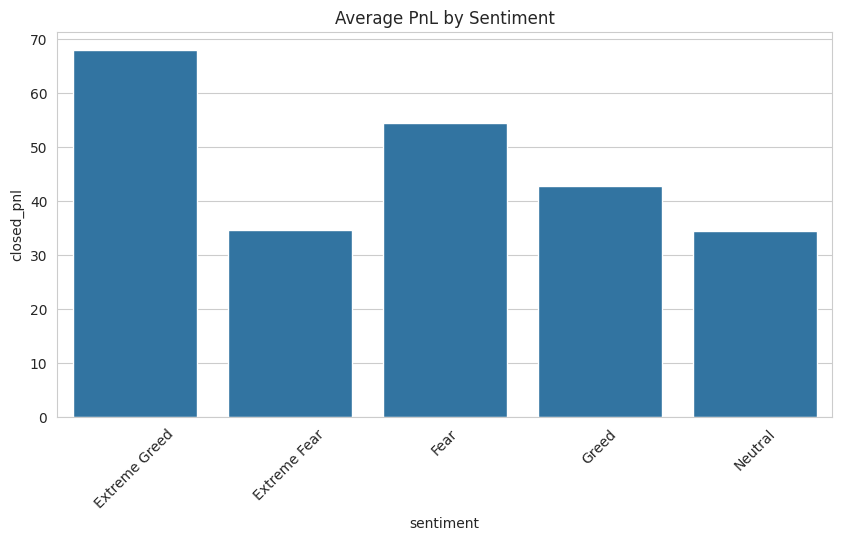

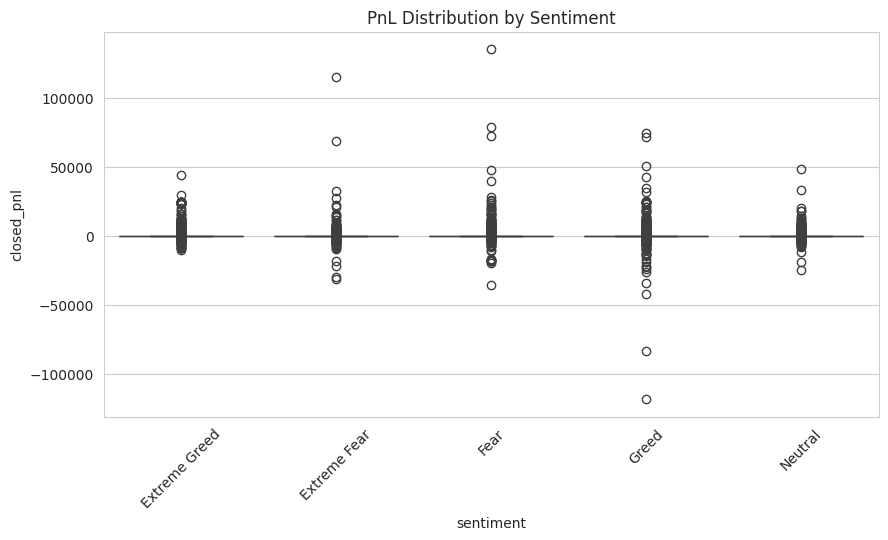

In [62]:
# Trades by sentiment
plt.figure()
sns.countplot(data=df_clean, x='sentiment')
plt.xticks(rotation=45)
plt.title('Trade Count by Sentiment')
plt.show()

# Avg PnL
plt.figure()
sns.barplot(data=df_clean, x='sentiment', y=pnl, errorbar=None)
plt.xticks(rotation=45)
plt.title('Average PnL by Sentiment')
plt.show()

# Boxplot
plt.figure()
# Filter to valid sentiment rows to avoid plotting errors
sns.boxplot(data=df_clean, x='sentiment', y=pnl)
plt.xticks(rotation=45)
plt.title('PnL Distribution by Sentiment')
plt.show()

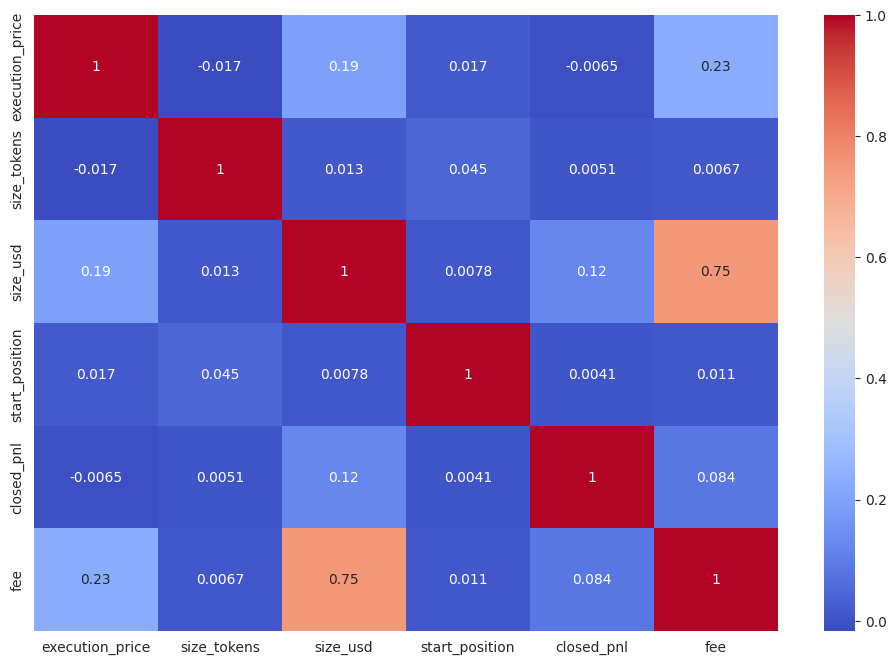

In [63]:
# Correlation
id_like = ['order_id','trade_id','timestamp']
num = df.select_dtypes(include=np.number).drop(columns=id_like, errors='ignore')
plt.figure(figsize=(12,8))
sns.heatmap(num.corr(),annot=True,cmap='coolwarm')
plt.show()


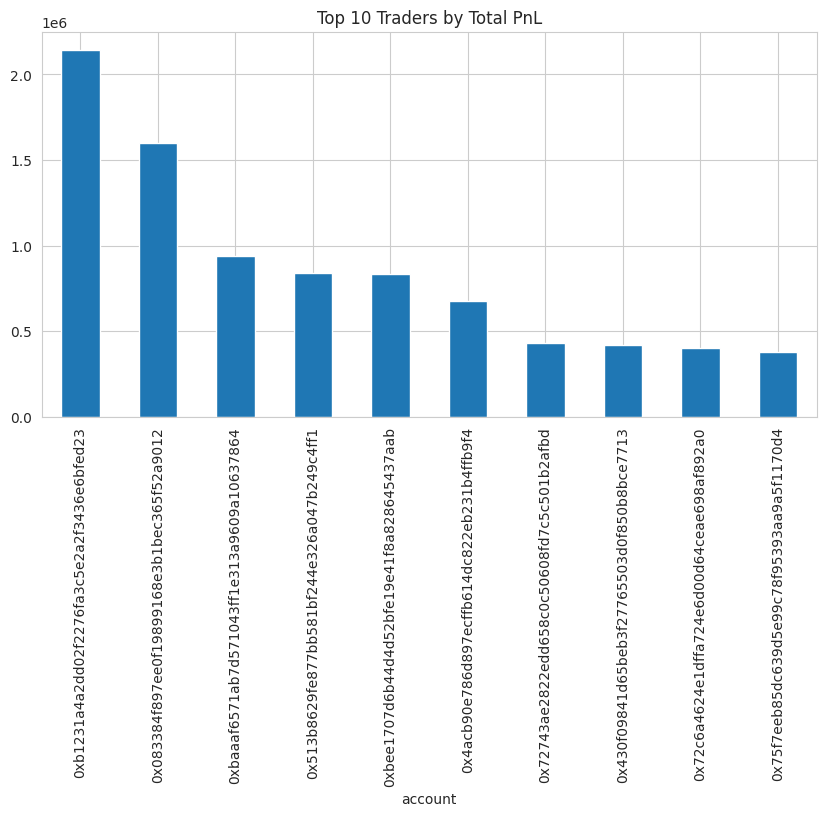

In [64]:
# Top traders
acct=[c for c in df.columns if 'account' in c][0]
top=df.groupby(acct)[pnl].sum().sort_values(ascending=False).head(10)
top.plot(kind='bar')
plt.title('Top 10 Traders by Total PnL')
plt.show()


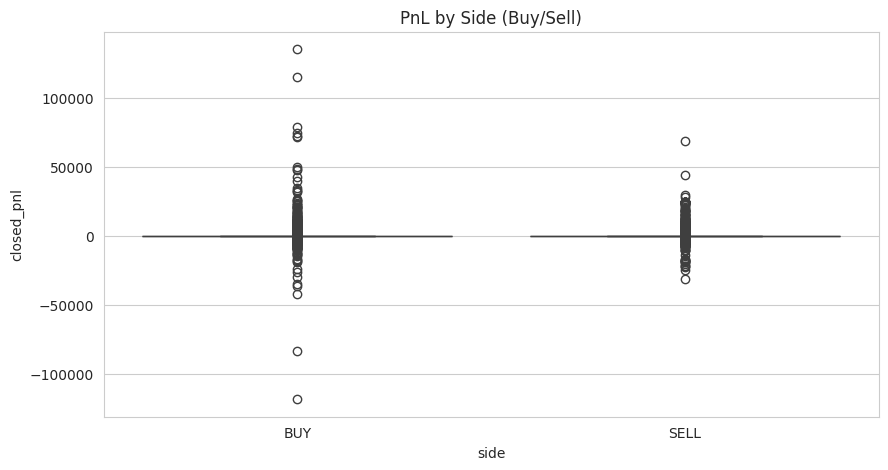

Liquidation/deleveraging rate by sentiment:
 sentiment
Greed            0.000179
Extreme Fear     0.000000
Extreme Greed    0.000000
Fear             0.000000
Neutral          0.000000
Name: is_liquidation, dtype: float64


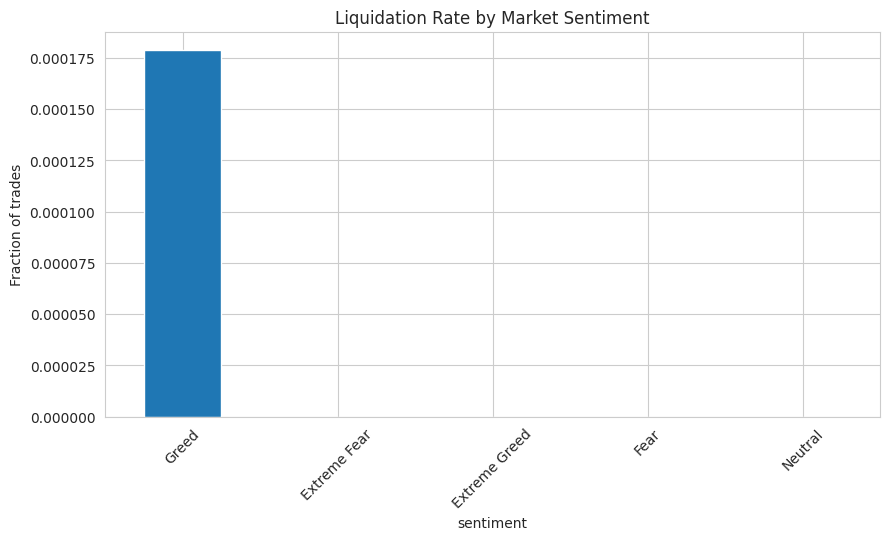

In [65]:
# Buy/Sell analysis
side=[c for c in df.columns if 'side' in c]
if side:
    plt.figure()
    sns.boxplot(data=df,x=side[0],y=pnl)
    plt.title('PnL by Side (Buy/Sell)')
    plt.show()
if 'direction' in df.columns:
    df['is_liquidation'] = df['direction'].str.contains('Liquidat|Deleverag', case=False, na=False)
    liq_rate = df.groupby('sentiment')['is_liquidation'].mean().sort_values(ascending=False)
    print("Liquidation/deleveraging rate by sentiment:\n", liq_rate)

    plt.figure()
    liq_rate.plot(kind='bar')
    plt.title('Liquidation Rate by Market Sentiment')
    plt.ylabel('Fraction of trades')
    plt.xticks(rotation=45)
    plt.show()


In [66]:
# Statistical test Fear vs Greed (if both exist)
if {'Fear','Greed'}.issubset(set(df['sentiment'].dropna().unique())):
    a=df[df.sentiment=='Fear'][pnl].dropna()
    b=df[df.sentiment=='Greed'][pnl].dropna()
    print(ttest_ind(a,b,equal_var=False))
else:
    print('Fear/Greed categories not found exactly; inspect sentiment labels.')


TtestResult(statistic=np.float64(1.8511431575014454), pvalue=np.float64(0.06415196288057486), df=np.float64(98144.4081634879))


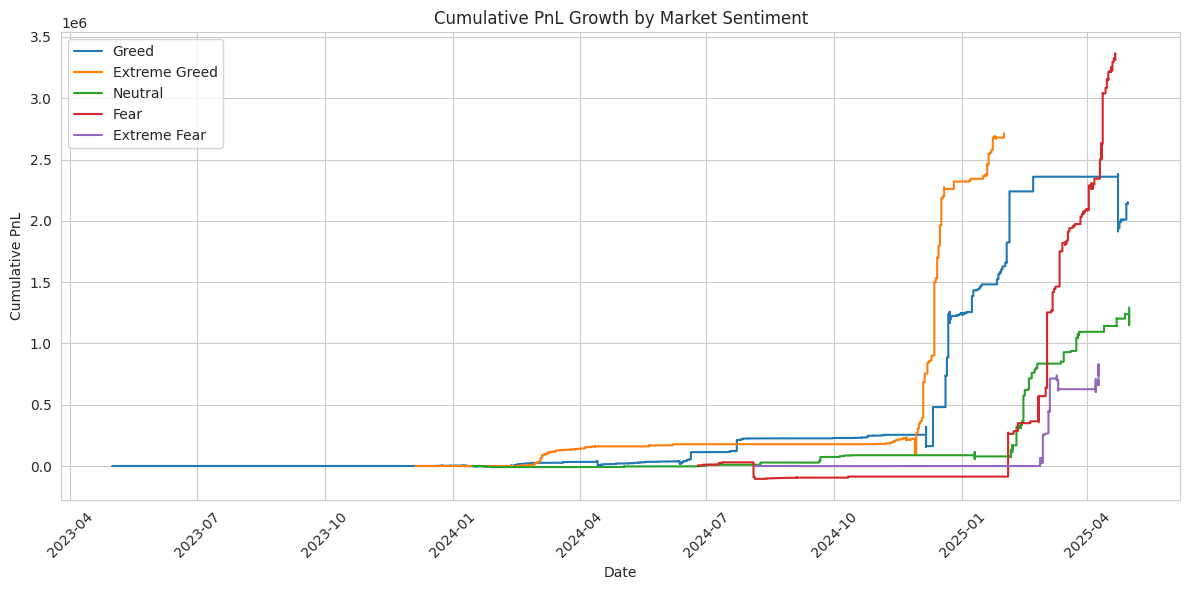

In [67]:
# Calculate Cumulative PnL over time by Sentiment
df_sorted = df_clean.sort_values('date')
df_sorted['cum_pnl'] = df_sorted.groupby('sentiment')[pnl].cumsum()

plt.figure(figsize=(12, 6))
for sentiment in df_sorted['sentiment'].unique():
    subset = df_sorted[df_sorted['sentiment'] == sentiment]
    plt.plot(subset['date'], subset['cum_pnl'], label=sentiment)

plt.title('Cumulative PnL Growth by Market Sentiment')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

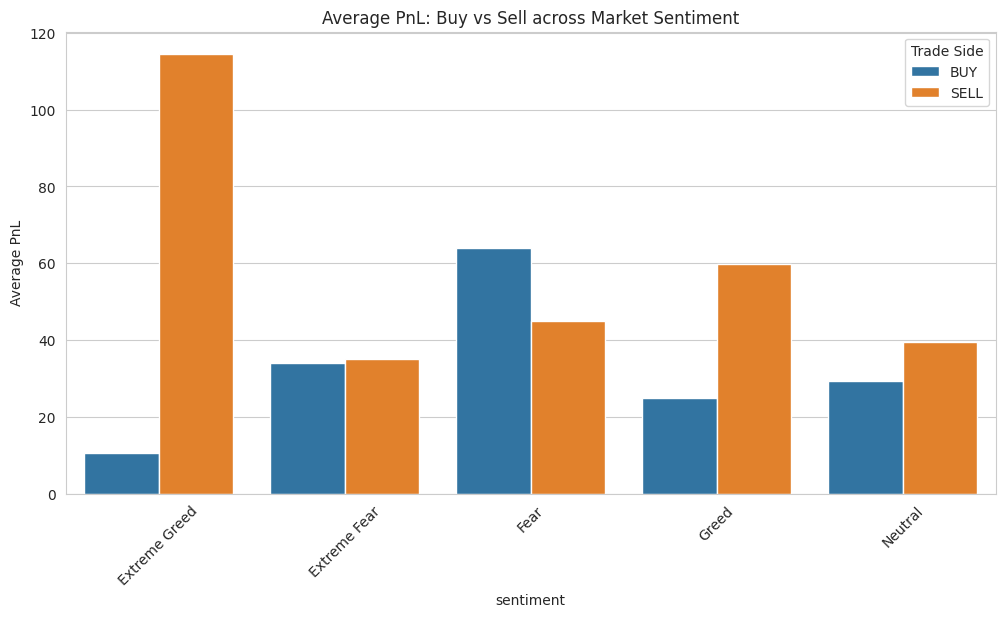

In [68]:
if 'side' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_clean, x='sentiment', y=pnl, hue='side', errorbar=None)
    plt.title('Average PnL: Buy vs Sell across Market Sentiment')
    plt.xticks(rotation=45)
    plt.ylabel('Average PnL')
    plt.legend(title='Trade Side')
    plt.show()
else:
    print("Column 'side' not found for side-by-side analysis.")

--- Risk/Reward Metrics by Sentiment ---
               Win Rate (%)  Profit Factor  Total Trades
Sentiment                                               
Extreme Fear          37.06           2.16         21400
Extreme Greed         46.49          11.02         39992
Fear                  42.08           6.66         61837
Greed                 38.48           3.03         50303
Neutral               39.70           4.32         37686


/tmp/ipykernel_3906/2851578352.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Win Rate (%)'], palette='viridis')


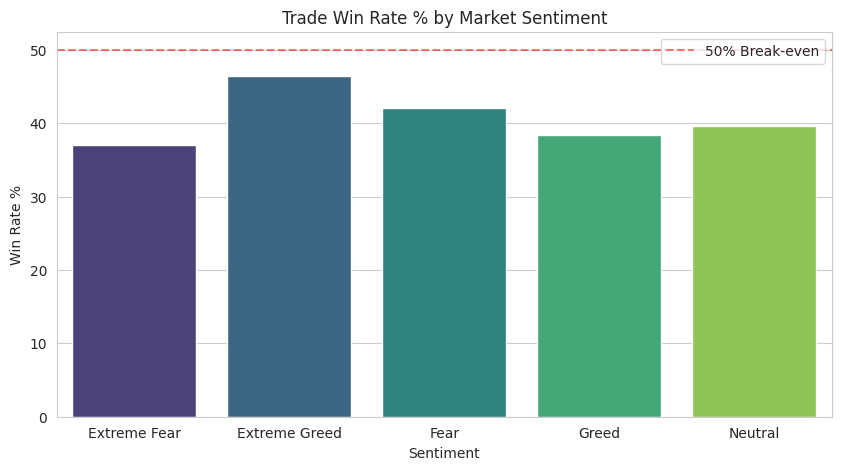

In [69]:
# Calculate Win Rate and Profit Factor per Sentiment
results = []
for label, group in df_clean.groupby('sentiment'):
    wins = group[group[pnl] > 0][pnl]
    losses = group[group[pnl] < 0][pnl].abs()

    win_rate = (len(wins) / len(group)) * 100 if len(group) > 0 else 0
    profit_factor = wins.sum() / losses.sum() if losses.sum() > 0 else np.inf

    results.append({
        'Sentiment': label,
        'Win Rate (%)': round(win_rate, 2),
        'Profit Factor': round(profit_factor, 2),
        'Total Trades': len(group)
    })

metrics_df = pd.DataFrame(results).set_index('Sentiment')
print("--- Risk/Reward Metrics by Sentiment ---")
print(metrics_df)

# Visualize Win Rate
plt.figure(figsize=(10, 5))
sns.barplot(x=metrics_df.index, y=metrics_df['Win Rate (%)'], palette='viridis')
plt.title('Trade Win Rate % by Market Sentiment')
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Break-even')
plt.ylabel('Win Rate %')
plt.legend()
plt.show()

# Business Insights

Replace this section after reviewing outputs.

- Which sentiment yields higher profitability?
- Does leverage or trade size increase during Greed?
- Are losses larger during Fear?
- Who are the most consistent traders?
- Recommendations for trading strategy.


### 1. Does trade size (USD) increase during Greed?
We will analyze the `size_usd` across different sentiments to see if traders take larger risks when the market is Greed-driven.

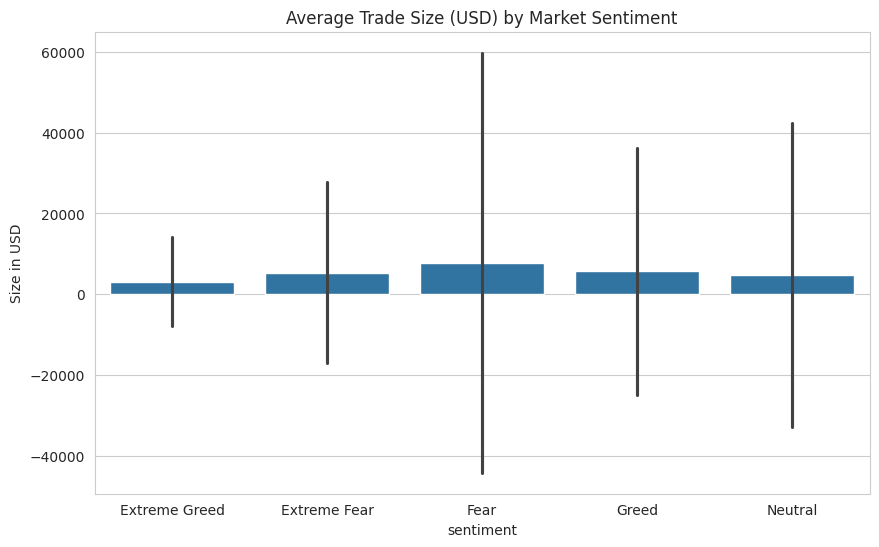

Average Trade Size by Sentiment:
sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


In [70]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='sentiment', y='size_usd', errorbar='sd')
plt.title('Average Trade Size (USD) by Market Sentiment')
plt.ylabel('Size in USD')
plt.show()

print("Average Trade Size by Sentiment:")
print(df_clean.groupby('sentiment')['size_usd'].mean())

### 2. Are losses larger during Fear?
We will filter for losing trades only and compare the average loss magnitude across regimes.

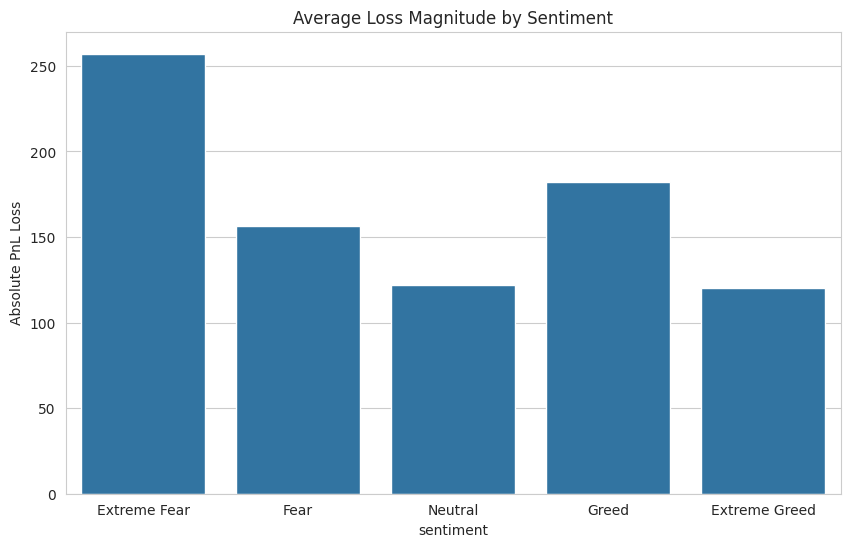

Average Loss Magnitude:
sentiment
Extreme Fear     257.099629
Extreme Greed    119.920289
Fear             156.662401
Greed            181.967329
Neutral          121.727849
Name: abs_loss, dtype: float64


In [71]:
losses_df = df_clean[df_clean[pnl] < 0].copy()
losses_df['abs_loss'] = losses_df[pnl].abs()

plt.figure(figsize=(10, 6))
sns.barplot(data=losses_df, x='sentiment', y='abs_loss', errorbar=None)
plt.title('Average Loss Magnitude by Sentiment')
plt.ylabel('Absolute PnL Loss')
plt.show()

print("Average Loss Magnitude:")
print(losses_df.groupby('sentiment')['abs_loss'].mean())

### 3. Who are the most consistent traders?
We define consistency as having a high Win Rate and a significant total PnL.

In [72]:
def get_consistency(group):
    wins = (group[pnl] > 0).sum()
    total = len(group)
    return pd.Series({
        'win_rate': (wins / total) * 100,
        'total_pnl': group[pnl].sum(),
        'trade_count': total
    })

# Filter for traders with at least 50 trades to ensure statistical significance
trader_consistency = df_clean.groupby('account').apply(get_consistency, include_groups=False)
top_consistent = trader_consistency[trader_consistency['trade_count'] > 50].sort_values('win_rate', ascending=False).head(10)

print("Top 10 Most Consistent Traders (min 50 trades):")
display(top_consistent)

Top 10 Most Consistent Traders (min 50 trades):


,win_rate,total_pnl,trade_count
account,,,
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,81.087638,379095.406711,9893.0
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,57.314149,72846.484272,417.0
0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,168658.004994,3239.0
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,48.622590,677747.050643,4356.0
0x430f09841d65beb3f27765503d0f850b8bce7713,48.423605,416541.872341,1237.0
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,47.590361,53496.247243,332.0
0xbaaaf6571ab7d571043ff1e313a9609a10637864,46.758211,940163.806220,21192.0
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,45.521472,-31203.599986,815.0
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,45.221296,14900.443047,1559.0
